<p align="center">
<a href="https://silvimetric.com"><img src="https://github.com/hobuinc/silvimetric/blob/main/docs/source/logo/Logos/PNG/SilviMeteric_Logo_2c.png?raw=true" width="50%"></a></p>

# SilviMetric Rainy Lake Demo

This notebook is adapted from `silvimetric_1_3_0_demo.ipynb` to read an existing Rainy Lake SilviMetric TileDB database from S3. The default database is `s3://rainy-lake-sivilmetric-31b-test/db`.


### Workflow

1. Install the Colab conda runtime and SilviMetric dependencies.
2. Configure S3 access for TileDB.
3. Open the existing Rainy Lake SilviMetric database.
4. Inspect database metadata.
5. Extract selected metrics to GeoTIFF rasters.

The original initialize, scan, shatter, delete, resume, restart, and custom-metric recreation cells are intentionally omitted from the runnable workflow because they mutate a database.


# Installations

## Install CondaColab

CondaColab requires the runtime to reset. Sometimes this doesn't take, or we have to wait for it to take effect (the ``sleep(30)``).

## Install SilviMetric dependencies

Install stuff from [Conda Forge](https://conda-forge.org/). Conda Forge is where [PDAL](https://pdal.io), [GDAL](https://gdal.org), and [TileDB](tiledb.com) are installed from. SilviMetric provides a [Conda environment file](https://github.com/hobuinc/silvimetric/raw/main/environment.yml) that describes everything it needs to operate.

** Important **
After all packages have been installed, the session must be restarted in order
to use them. The last 3 lines in this section will do that for you, and then you may move to the next section.

In [9]:
%%capture
%env PROJ_NETWORK=TRUE

!mamba update --all --yes
!mamba install silvimetric rasterio geopandas folium mapclassify openssl sqlite pystac --yes

# in order to make sure we're working with the newly installed packages, we
# must kill the session and restart. A message will appear saying the session
# has terminated for unknown reasons, this is expected

In [10]:
%env PROJ_NETWORK=TRUE


!pdal --version
!gdalinfo --version
!silvimetric --version
!mamba list tiledb
!mamba list openssl
!mamba list sqlite


env: PROJ_NETWORK=TRUE
--------------------------------------------------------------------------------
pdal 2.10.2 (git-version: Release)
--------------------------------------------------------------------------------

GDAL 3.13.2 "Iowa City", released 2026/07/20
silvimetric, version 2.0.1
List of packages in environment: "/Users/hobu/miniforge3"

  Name       Version  Build            Channel    
────────────────────────────────────────────────────
  tiledb     2.30.1   h0b915bd_21      conda-forge
  tiledb-py  0.36.0   py312h519b83c_1  conda-forge
List of packages in environment: "/Users/hobu/miniforge3"

  Name       Version  Build         Channel    
─────────────────────────────────────────────────
  openssl    3.6.3    hd24854e_1    conda-forge
  pyopenssl  26.4.0   pyhcf101f3_0  conda-forge
List of packages in environment: "/Users/hobu/miniforge3"

  Name       Version  Build       Channel    
───────────────────────────────────────────────
  libsqlite  3.53.4   h1ae2325_0  co

## Setup

This notebook reads a public S3-backed TileDB database. It configures TileDB directly for unsigned public reads in `us-west-2`, so no AWS credentials or `AWS_*` environment variables are required.


In [11]:
import os
import json
from pathlib import Path

import tiledb
import rasterio
from rasterio.plot import show
from rasterio.windows import get_data_window, transform
import silvimetric as sm
from silvimetric.resources.metrics.stats import statistics

os.environ.setdefault("SILVIMETRIC_TILEDB_S3_REGION", "us-west-2")
os.environ.setdefault("SILVIMETRIC_TILEDB_NO_SIGN_REQUEST", "true")
os.environ.setdefault("SILVIMETRIC_TILEDB_MAX_INCOMPLETE_RETRIES", "1000")

tiledb_config = tiledb.Config()
tiledb_config["vfs.s3.region"] = os.environ["SILVIMETRIC_TILEDB_S3_REGION"]
tiledb_config["vfs.s3.no_sign_request"] = os.environ["SILVIMETRIC_TILEDB_NO_SIGN_REQUEST"]
tiledb_config["vfs.s3.connect_scale_factor"] = "25"
tiledb_config["vfs.s3.connect_max_retries"] = "10"
tdb_ctx = tiledb.Ctx(tiledb_config)

log = sm.Log(10)
db_path = "s3://rainy-lake-sivilmetric-31b-test/db"
out_dir = Path.cwd() / "rasters"
out_dir.mkdir(exist_ok=True)

db_path, out_dir.as_posix()


('s3://rainy-lake-sivilmetric-31b-test/db',
 '/Users/hobu/dev/git/silvimetric-hobu/notebooks/rasters')

## Open the Rainy Lake Database

The database is already initialized and populated. This cell checks the TileDB object type and prints a concise SilviMetric info summary.


In [12]:
try:
    object_type = tiledb.object_type(db_path, ctx=tdb_ctx)
except tiledb.TileDBError as error:
    raise RuntimeError(
        f"Could not open TileDB database at {db_path}. "
        "Check that the S3 bucket/key exists and is publicly readable."
    ) from error

print(f"TileDB object type: {object_type}")

if object_type == "group":
    with tiledb.Group(db_path, "r", ctx=tdb_ctx) as group:
        shard_members = [(member.name, member.uri) for member in group]
    first_shard_uri = shard_members[0][1]
    print(f"Shard count: {len(shard_members)}")
    print(f"First shard: {first_shard_uri}")
else:
    shard_members = []
    first_shard_uri = db_path

# Avoid sm.info(db_path) here: group info opens every shard, which is
# expensive over public S3. Use the first shard for a quick schema check.
quick_info = sm.info(first_shard_uri, concise=True)
print(json.dumps(quick_info, indent=2, default=str)[:5000])


TileDB object type: group
Shard count: 276
First shard: s3://rainy-lake-sivilmetric-31b-test/db/shards/-10235450-6075590--10235330-6077710
{
  "attributes": [
    {
      "name": "Z",
      "dtype": "<f8"
    },
    {
      "name": "NumberOfReturns",
      "dtype": "|u1"
    },
    {
      "name": "ReturnNumber",
      "dtype": "|u1"
    },
    {
      "name": "Intensity",
      "dtype": "<u2"
    }
  ],
  "metadata": {
    "tdb_dir": "s3://sm-smoke-056176271256-9bed1405-be4d-436a-ab3d-017de38017dd/db/shards/-10235450-6075590--10235330-6077710",
    "root": [
      -10245570.0,
      6072930.0,
      -10227550.0,
      6090950.0
    ],
    "crs": {
      "$schema": "https://proj.org/schemas/v0.7/projjson.schema.json",
      "type": "ProjectedCRS",
      "name": "WGS 84 / Pseudo-Mercator",
      "base_crs": {
        "type": "GeographicCRS",
        "name": "WGS 84",
        "datum_ensemble": {
          "name": "World Geodetic System 1984 ensemble",
          "members": [
            {

In [13]:
storage = sm.Storage.from_db(first_shard_uri, ctx=tdb_ctx)

print("Root bounds:", storage.config.root)
print("CRS:", storage.config.crs)
print("Resolution:", storage.config.resolution)
print("Attributes:", [attr.name for attr in storage.config.attrs])
print("Metrics:", [metric.name for metric in storage.config.metrics])


Root bounds: [-10245570.0, 6072930.0, -10227550.0, 6090950.0]
CRS: {"$schema": "https://proj.org/schemas/v0.7/projjson.schema.json", "type": "ProjectedCRS", "name": "WGS 84 / Pseudo-Mercator", "base_crs": {"type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)", "id": {"authority": "EPSG", "code": 1166}}, {"name": "World Geodetic System 1984 (G730)", "id": {"authority": "EPSG", "code": 1152}}, {"name": "World Geodetic System 1984 (G873)", "id": {"authority": "EPSG", "code": 1153}}, {"name": "World Geodetic System 1984 (G1150)", "id": {"authority": "EPSG", "code": 1154}}, {"name": "World Geodetic System 1984 (G1674)", "id": {"authority": "EPSG", "code": 1155}}, {"name": "World Geodetic System 1984 (G1762)", "id": {"authority": "EPSG", "code": 1156}}, {"name": "World Geodetic System 1984 (G2139)", "id": {"authority": "EPSG", "code": 1309}}, {"name": "World Geodetic System 1984

## Extract Metric Rasters

By default, this extracts a single `Intensity` / `max` raster from the first public shard so the demo completes quickly. The full Rainy Lake group has hundreds of shards; extracting the whole group is intentionally left as an optional cell.


In [14]:
import datetime

available_attr_names = {attr.name for attr in storage.config.attrs}
available_metric_names = {metric.name for metric in storage.config.metrics}

extract_attrs = [sm.Attributes["Intensity"]] if "Intensity" in available_attr_names else None
extract_metrics = [statistics["max"]] if "max" in available_metric_names else None

extract_config = sm.ExtractConfig(
    tdb_dir=first_shard_uri,
    log=log,
    out_dir=out_dir.as_posix(),
    attrs=extract_attrs,
    metrics=extract_metrics,
    date=(datetime.datetime(2021, 4, 1), datetime.datetime(2021, 6, 1)),
)

print(f"Extracting demo raster from {first_shard_uri}")
sm.extract(extract_config)
sorted(path.name for path in out_dir.glob("*.tif"))


Extracting demo raster from s3://rainy-lake-sivilmetric-31b-test/db/shards/-10235450-6075590--10235330-6077710
2026-08-12 10:18:21,636 - silvimetric - DEBUG - debug:145 - Extracting metrics ['m_Intensity_max']


['m_Intensity_max.tif']

/Users/hobu/dev/git/silvimetric-hobu/notebooks/rasters/m_Intensity_max.tif
{'driver': 'GTiff', 'dtype': 'float32', 'nodata': -9999.0, 'width': 6, 'height': 106, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]'), 'transform': Affine(20.0, 0.0, -10245570.0,
       0.0, -20.0, 6090950.0), 'blockxsize': 6, 'blockysize': 106, 'tiled': F

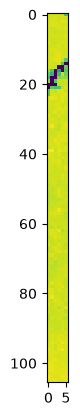

In [15]:
raster_paths = sorted(out_dir.glob("*.tif"))
raster_path = raster_paths[0]

with rasterio.open(raster_path) as raster:
    profile = raster.profile.copy()
    data_window = get_data_window(raster.read(masked=True))
    data_transform = transform(data_window, raster.transform)
    profile.update(
        transform=data_transform,
        height=data_window.height,
        width=data_window.width,
    )
    print(raster_path)
    print(profile)
    show(raster.read(window=data_window))


## Optional: Extract the Full Database

The following cell is intentionally commented out. Uncomment it only when you want every stored attribute/metric combination written to GeoTIFF.


In [16]:
import datetime

# full_extract_config = sm.ExtractConfig(
#     tdb_dir=db_path,
#     log=log,
#     out_dir=(Path.cwd() / "all_rasters").as_posix(),
#     attrs=None,
#     metrics=None,
# )
# sm.extract(full_extract_config)
